In [6]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

In [7]:
# load dataset
df = pd.read_csv("E:/Car-Resale-Price-Prediction/dataset/used_cars_dataset.csv")
print(df.shape)
df.head()

(1050, 14)


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Nissan Terrano XV,Hyderabad,2007,127225,Diesel,Automatic,Second,24.16 kmpl,1561 CC,131.39 bhp,7.0,41.3 Lakh,10.89
1,1,Hyundai i20 Sportz,Pune,2010,102800,Diesel,Automatic,First,19.29 kmpl,1973 CC,204.57 bhp,5.0,NaN,18.96
2,2,Skoda Yeti Ambition,Delhi,2006,120317,Diesel,Manual,First,19.3 kmpl,2186 CC,175.17 bhp,7.0,63.11 Lakh,15.79
3,3,Audi Q3 2.0 TDI,Hyderabad,2015,49027,Diesel,Automatic,First,18.88 kmpl,1812 CC,203.29 bhp,7.0,98.2 Lakh,63.75
4,4,Hyundai i10 Magna,Pune,2007,207392,Diesel,Automatic,First,25.22 kmpl,1181 CC,89.93 bhp,7.0,30.37 Lakh,8.83


In [8]:
df.info()
print("Duplicates:", df.duplicated().sum())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              1050 non-null   int64  
 1   Name               1050 non-null   object 
 2   Location           1050 non-null   object 
 3   Year               1050 non-null   int64  
 4   Kilometers_Driven  1050 non-null   int64  
 5   Fuel_Type          1050 non-null   object 
 6   Transmission       1050 non-null   object 
 7   Owner_Type         1050 non-null   object 
 8   Mileage            1050 non-null   object 
 9   Engine             1050 non-null   object 
 10  Power              1050 non-null   object 
 11  Seats              1050 non-null   float64
 12  New_Price          684 non-null    object 
 13  Price              1050 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 115.0+ KB
Duplicates: 0
S.No.                  0
Name                  

## Cleaning

In [9]:
# drop irrelevant / mostly-empty columns
df = df.drop(columns=[c for c in ["New_Price", "S.No."] if c in df.columns])

# strip units and convert to numeric
df['Mileage'] = df['Mileage'].astype(str).str.split().str[0].astype(float)
df['Engine']  = df['Engine'].astype(str).str.split().str[0].astype(float)
df['Power']   = pd.to_numeric(df['Power'].astype(str).str.split().str[0], errors='coerce')

df.dtypes

Name                  object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage              float64
Engine               float64
Power                float64
Seats                float64
Price                float64
dtype: object

In [10]:
# fill remaining numeric NaNs with median (created by unit-stripping / bad values)
for col in ['Mileage', 'Engine', 'Power', 'Seats']:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

In [11]:
df['Fuel_Type'].value_counts(), df['Transmission'].value_counts(), df['Owner_Type'].value_counts()

(Fuel_Type
 Diesel    535
 Petrol    466
 CNG        42
 LPG         7
 Name: count, dtype: int64,
 Transmission
 Manual       569
 Automatic    481
 Name: count, dtype: int64,
 Owner_Type
 First             703
 Second            265
 Third              59
 Fourth & Above     23
 Name: count, dtype: int64)

## EDA

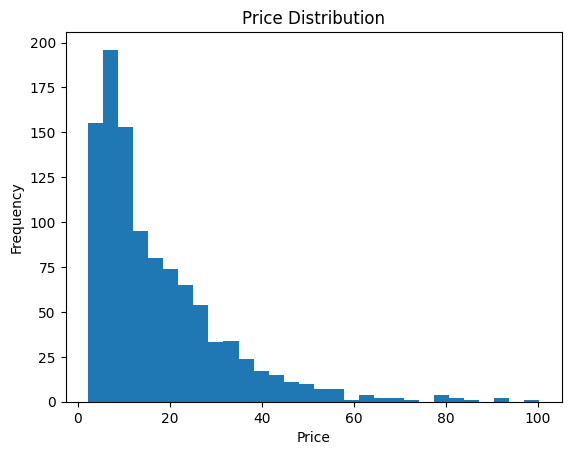

In [12]:
plt.hist(df['Price'], bins=30)
plt.xlabel("Price"); plt.ylabel("Frequency"); plt.title("Price Distribution")
plt.show()

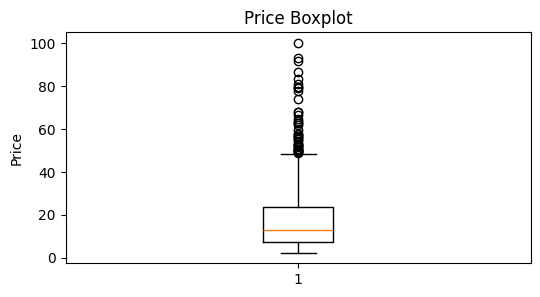

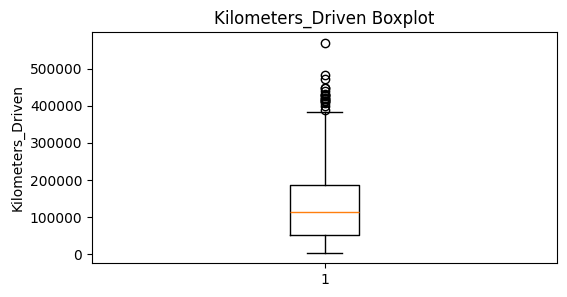

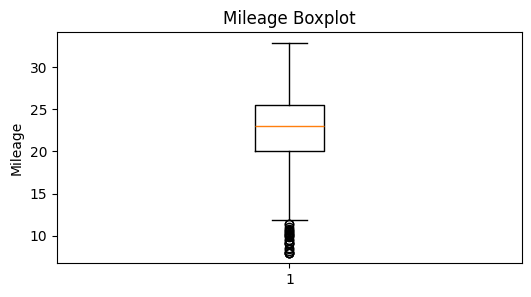

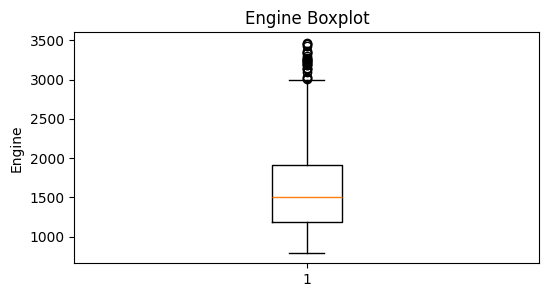

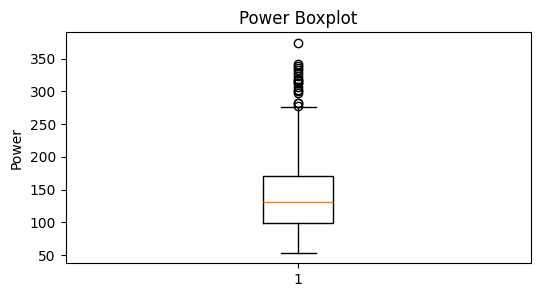

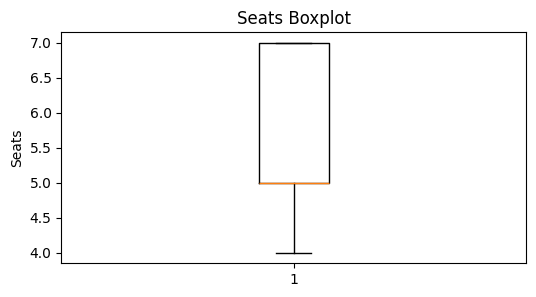

In [13]:
for col in ['Price', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col].dropna())
    plt.title(f'{col} Boxplot')
    plt.ylabel(col)
    plt.show()

In [14]:
# remove extreme outliers using IQR (helps R² a lot on this dataset)
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Lower:", lower, "Upper:", upper)

before = df.shape[0]
df = df[(df['Price'] >= max(lower, 0)) & (df['Price'] <= upper)]
print(f"Removed {before - df.shape[0]} outlier rows, {df.shape[0]} rows remain")

Lower: -17.563750000000002 Upper: 48.346250000000005
Removed 43 outlier rows, 1007 rows remain


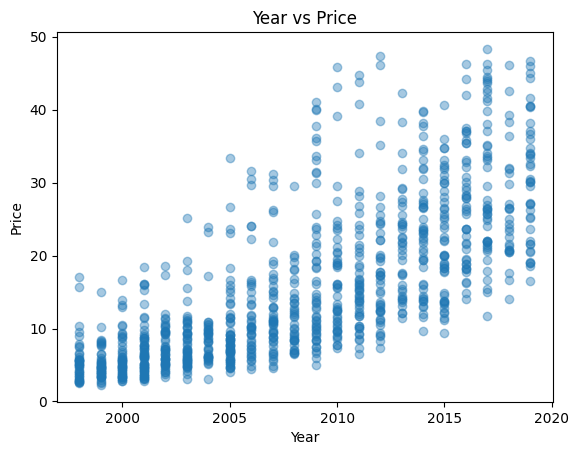

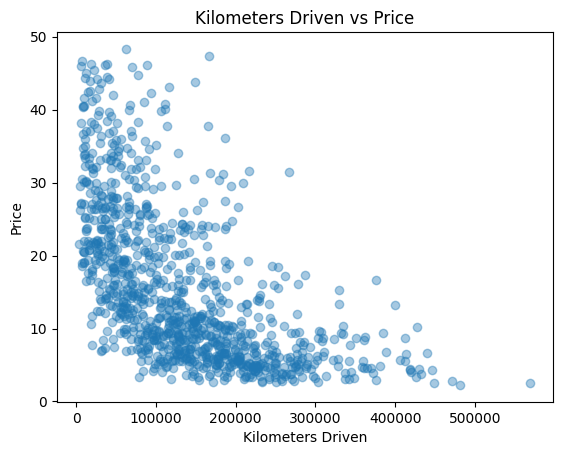

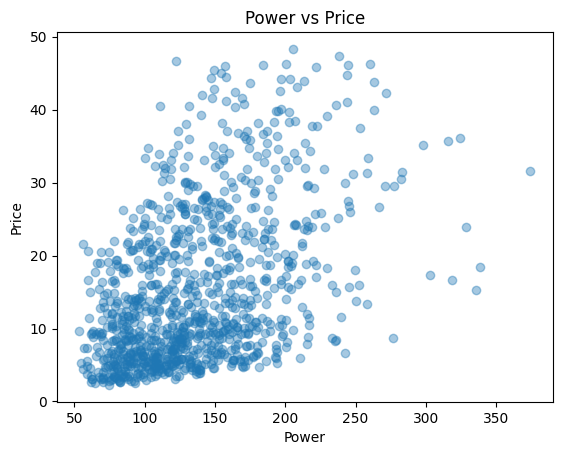

In [15]:
plt.scatter(df['Year'], df['Price'], alpha=0.4)
plt.xlabel('Year'); plt.ylabel('Price'); plt.title('Year vs Price'); plt.show()

plt.scatter(df['Kilometers_Driven'], df['Price'], alpha=0.4)
plt.xlabel('Kilometers Driven'); plt.ylabel('Price'); plt.title('Kilometers Driven vs Price'); plt.show()

plt.scatter(df['Power'], df['Price'], alpha=0.4)
plt.xlabel('Power'); plt.ylabel('Price'); plt.title('Power vs Price'); plt.show()

## Feature engineering

`Car_Age` and `Brand` are engineered from `Year` and `Name`. **This means the trained pipeline expects `Car_Age`/`Brand` as inputs — not raw `Year`/`Name`/`Car_Model` — so `app.py` must compute these same features before calling `.predict()`.**

In [16]:
CURRENT_YEAR = 2026
df["Car_Age"] = CURRENT_YEAR - df["Year"]
df["Brand"] = df["Name"].str.split().str[0]

print(df["Brand"].value_counts().head(20))

Brand
Maruti           136
Hyundai          132
Tata              92
Mahindra          80
Honda             72
Toyota            66
Ford              60
Volkswagen        58
Renault           51
Skoda             45
Nissan            40
Chevrolet         38
Jeep              21
Datsun            15
Audi              14
Mitsubishi        12
Fiat              12
BMW               10
Mercedes-Benz      9
Force              8
Name: count, dtype: int64


In [17]:
# group rare brands into "Other" so OneHotEncoder generalizes better
brand_counts = df["Brand"].value_counts()
rare_brands = brand_counts[brand_counts < 10].index
df["Brand"] = df["Brand"].replace(rare_brands, "Other")
df["Brand"].value_counts()

Brand
Maruti        136
Hyundai       132
Tata           92
Mahindra       80
Honda          72
Toyota         66
Ford           60
Volkswagen     58
Other          53
Renault        51
Skoda          45
Nissan         40
Chevrolet      38
Jeep           21
Datsun         15
Audi           14
Fiat           12
Mitsubishi     12
BMW            10
Name: count, dtype: int64

## Train / test split

**No `pd.get_dummies()` here** — raw categorical columns are kept as-is, and the `OneHotEncoder` inside the pipeline handles them. That way the saved `.pkl` can accept a plain DataFrame with these exact 11 raw columns at inference time.

In [18]:
categorical_cols = ["Brand", "Location", "Fuel_Type", "Transmission", "Owner_Type"]
numerical_cols   = ["Car_Age", "Kilometers_Driven", "Mileage", "Engine", "Power", "Seats"]

X = df[categorical_cols + numerical_cols]
y = df["Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1007, 11)
y shape: (1007,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train:", X_train.shape[0])
print("X_test :", X_test.shape[0])

X_train: 805
X_test : 202


## Pipeline + model

The preprocessor is fit **inside** the pipeline and the pipeline itself is what gets trained — it is never overwritten by a bare estimator (that was the original bug).

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
def evaluate(model, name):
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    print(f"--- {name} ---")
    print(f"MAE : {mae:.3f}")
    print(f"MSE : {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²  : {r2:.4f}")
    return y_pred, r2

y_pred_gb, r2_gb = evaluate(gb_model, "Gradient Boosting")

--- Gradient Boosting ---
MAE : 1.474
MSE : 4.732
RMSE: 2.175
R²  : 0.9553


### Comparison: Random Forest and plain Linear Regression
(kept only for reference — Gradient Boosting is what gets saved below, since it scored highest)

In [22]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=400, random_state=42, n_jobs=-1
    ))
])
rf_model.fit(X_train, y_train)
_ = evaluate(rf_model, "Random Forest")

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
lr_model.fit(X_train, y_train)
_ = evaluate(lr_model, "Linear Regression")

--- Random Forest ---
MAE : 1.795
MSE : 7.253
RMSE: 2.693
R²  : 0.9315
--- Linear Regression ---
MAE : 3.242
MSE : 17.834
RMSE: 4.223
R²  : 0.8316


In [23]:
# actual vs predicted (using the Gradient Boosting model)
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_gb
})
comparison.head(10)

,Actual Price,Predicted Price
0,11.66,9.193020
1,25.56,24.974484
2,10.45,13.013225
3,5.32,4.919256
4,15.75,19.824030
5,5.27,6.719301
6,8.37,6.833894
7,20.72,21.347244
8,26.43,25.311771
9,9.49,10.365581


In [24]:
# feature importance
ohe = gb_model.named_steps["preprocessor"].named_transformers_["cat"]
feature_names = list(ohe.get_feature_names_out(categorical_cols)) + numerical_cols
importances = gb_model.named_steps["regressor"].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
feat_imp.head(15)

Car_Age              0.576671
Engine               0.238804
Power                0.090565
Kilometers_Driven    0.036215
Brand_Other          0.021102
Owner_Type_First     0.007162
Brand_Audi           0.003490
Mileage              0.003365
Brand_Skoda          0.002990
Brand_Hyundai        0.002284
Brand_BMW            0.001925
Owner_Type_Third     0.001714
Brand_Jeep           0.001659
Brand_Toyota         0.001564
Location_Kochi       0.001084
dtype: float64

In [27]:
## (Optional) Hyperparameter tuning
param_grid = {
    "regressor__n_estimators": [300, 400, 500],
    "regressor__learning_rate": [0.03, 0.05, 0.1],
    "regressor__max_depth": [3, 4, 5]
}

grid = GridSearchCV(
    gb_model, param_grid, cv=3, scoring="r2", n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best_model = grid.best_estimator_
_ = evaluate(best_model, "Tuned Gradient Boosting")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best params: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 4, 'regressor__n_estimators': 500}
--- Tuned Gradient Boosting ---
MAE : 1.465
MSE : 4.668
RMSE: 2.161
R²  : 0.9559


In [26]:
final_model = best_model if "best_model" in dir() else gb_model

with open("car_price_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

print("Model saved successfully!")
print("Expected input columns at inference time:", categorical_cols + numerical_cols)

Model saved successfully!
Expected input columns at inference time: ['Brand', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Car_Age', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']
